In [276]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

In [277]:
df=pd.read_csv("train.csv")
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [278]:
df.shape

(3000, 23)

In [279]:
df.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [280]:
df.describe(include='object')

,belongs_to_collection,genres,homepage,imdb_id,original_language,original_title,overview,poster_path,production_companies,production_countries,release_date,spoken_languages,status,tagline,title,Keywords,cast,crew
count,604,2993,946,3000,3000,3000,2992,2999,2844,2945,3000,2980,3000,2403,3000,2724,2987,2984
unique,422,872,941,3000,36,2975,2992,2999,2383,321,2398,401,2,2400,2969,2648,2975,2984
top,"[{'id': 645, 'name': 'James Bond Collection', ...","[{'id': 18, 'name': 'Drama'}]",http://www.transformersmovie.com/,tt2637294,en,Joshua,"When Lou, who has become the ""father of the In...",/tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg,"[{'name': 'Paramount Pictures', 'id': 4}]","[{'iso_3166_1': 'US', 'name': 'United States o...",9/10/10,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Based on a true story.,The Magnificent Seven,"[{'id': 10183, 'name': 'independent film'}]",[],"[{'credit_id': '59ac067c92514107af02c8c8', 'de..."
freq,16,266,4,1,2575,2,1,1,51,1752,5,1817,2996,3,2,27,13,1


In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

# Data preprocessing

In [282]:
df.columns

Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')

## Missing Value Analysis

In [283]:
print(df.isnull().sum())

id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [284]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing[missing > 0]) 

belongs_to_collection    79.866667
homepage                 68.466667
tagline                  19.900000
Keywords                  9.200000
production_companies      5.200000
production_countries      1.833333
spoken_languages          0.666667
crew                      0.533333
cast                      0.433333
overview                  0.266667
genres                    0.233333
runtime                   0.066667
poster_path               0.033333
dtype: float64


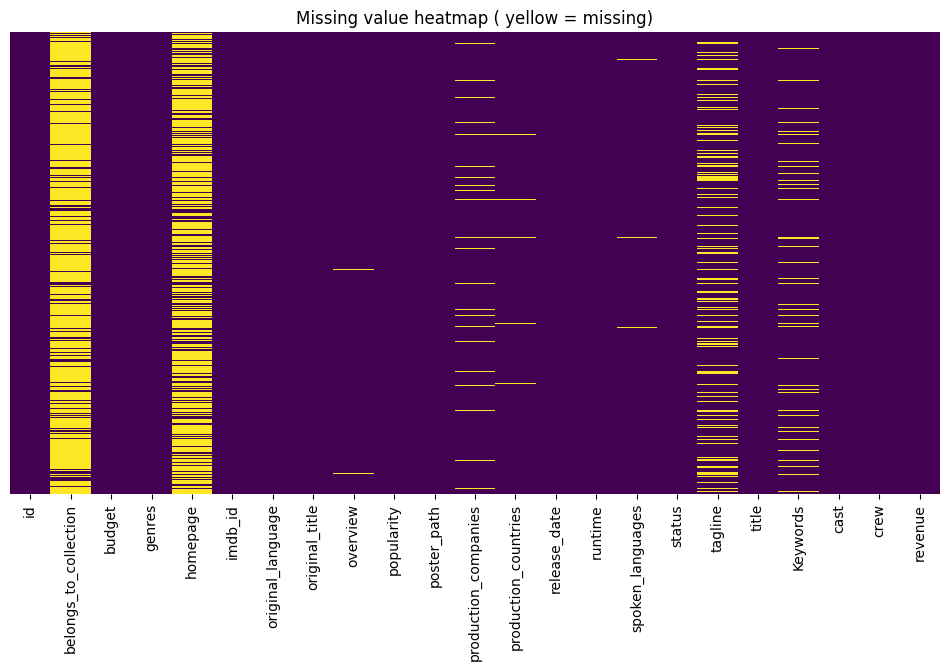

In [285]:
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),          
    cbar=False,           
    yticklabels=False,    
    cmap='viridis'        
)
plt.title('Missing value heatmap ( yellow = missing)')
plt.show()

In [286]:
df['runtime'].fillna(df['runtime'].median(), inplace=True)

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_25779/530401232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime'].fillna(df['runtime'].median(), inplace=True)


## Duplicate

In [287]:
df.duplicated().sum()

np.int64(0)

In [288]:
print("Zero budget:", (df['budget'] == 0).sum())
print("Zero revenue:", (df['revenue'] == 0).sum())

Zero budget: 812
Zero revenue: 0


In [289]:
df = df[(df['budget'] > 0)]

columns='id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'

In [290]:
df.iloc[0]

id                                                                       1
belongs_to_collection    [{'id': 313576, 'name': 'Hot Tub Time Machine ...
budget                                                            14000000
genres                                      [{'id': 35, 'name': 'Comedy'}]
homepage                                                               NaN
imdb_id                                                          tt2637294
original_language                                                       en
original_title                                      Hot Tub Time Machine 2
overview                 When Lou, who has become the "father of the In...
popularity                                                        6.575393
poster_path                               /tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg
production_companies     [{'name': 'Paramount Pictures', 'id': 4}, {'na...
production_countries     [{'iso_3166_1': 'US', 'name': 'United States o...
release_date             

In [291]:
df['belongs_to_collection'].iloc[0]

"[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]"

In [292]:
df['belongs_to_collection'].values

array(["[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]",
       "[{'id': 107674, 'name': 'The Princess Diaries Collection', 'poster_path': '/wt5AMbxPTS4Kfjx7Fgm149qPfZl.jpg', 'backdrop_path': '/zSEtYD77pKRJlUPx34BJgUG9v1c.jpg'}]",
       nan, ..., nan, nan, nan], dtype=object)

In [293]:
df['genres'].values

array(["[{'id': 35, 'name': 'Comedy'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 18, 'name': 'Drama'}]", ...,
       "[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}, {'id': 53, 'name': 'Thriller'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}]"],
      dtype=object)

In [294]:
df['production_companies'].iloc[0]

"[{'name': 'Paramount Pictures', 'id': 4}, {'name': 'United Artists', 'id': 60}, {'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]"

In [295]:
def extract_collection_features(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return pd.Series([None])
    
    
    if isinstance(x, list) and len(x) > 0:
        return pd.Series([                    
            x[0].get('name')       
        ])
    
    return pd.Series([None])

column created:has_collection

In [296]:
df['collection_name']=df['belongs_to_collection'].apply(extract_collection_features)

In [297]:
df['has_collection'] = df['collection_name'].apply(lambda x: 1 if x!=None  else 0)

In [298]:
def extract_names(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return []
    
    if isinstance(x, list):
        return [i.get('name') for i in x if isinstance(i, dict) and 'name' in i]
    
    return []

In [299]:
df['genres_list']=df['genres'].apply(extract_names)

In [300]:
df['genre_count'] = df['genres_list'].apply(len)

In [301]:
df['has_homepage'] = df['homepage'].notnull().astype(int)

In [302]:
df['original_language'].value_counts()

original_language
en    1943
hi      39
fr      39
ru      28
ja      18
es      17
zh      14
it      13
ta      13
ko      11
de      11
cn       8
pt       4
nl       3
ro       3
fi       2
sv       2
ml       2
te       2
da       2
pl       2
tr       1
id       1
vi       1
mr       1
fa       1
nb       1
no       1
he       1
ur       1
el       1
sr       1
hu       1
Name: count, dtype: int64

In [303]:
top_langs = df['original_language'].value_counts().index[:5]

df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

In [304]:
df = pd.get_dummies(df, columns=['original_language'], drop_first=True,dtype=int)

In [305]:
df['overview_length'] = df['overview'].fillna('').apply(len)
df['overview_word_count'] = df['overview'].fillna('').apply(lambda x: len(x.split()))

In [306]:
df['company_names'] = df['production_companies'].apply(extract_names)

In [307]:
all_companies = df['company_names'].explode()

freq = all_companies.value_counts()

df['company_score'] = df['company_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [308]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dayofweek'] = df['release_date'].dt.dayofweek

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_25779/1937282013.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


In [309]:
df['keyword_names'] = df['Keywords'].apply(extract_names)

In [310]:
all_keywords = df['keyword_names'].explode()
freq = all_keywords.value_counts()

df['keyword_score'] = df['keyword_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [311]:
df['cast_names'] = df['cast'].apply(extract_names)

In [312]:
all_cast = df['cast_names'].explode()

In [313]:
freq = all_cast.value_counts()

df['cast_score'] = df['cast_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [314]:
def extract_director(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return None
    
    if isinstance(x, list):
        for i in x:
            if isinstance(i, dict) and i.get('job') == 'Director':
                return i.get('name')   # ✅ string
    
    return None

In [315]:
df['director'] = df['crew'].apply(extract_director)

In [316]:
freq = df['director'].value_counts()
df['director_score'] = df['director'].map(freq)

In [317]:
df.drop(columns=['belongs_to_collection','id','collection_name','genres_list','genres','homepage', 'imdb_id','original_title','overview','poster_path','production_companies','company_names','production_countries', 'release_date','status','tagline','title','keyword_names','Keywords','cast_names','cast','crew','director',], inplace=True)

In [318]:
df.head()

,budget,popularity,runtime,spoken_languages,revenue,has_collection,genre_count,has_homepage,original_language_fr,original_language_hi,...,original_language_ru,overview_length,overview_word_count,company_score,release_year,release_month,release_dayofweek,keyword_score,cast_score,director_score
0,14000000,6.575393,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",12314651,1,1,0,0,0,...,0,155,29,235,2015,2,4,196,84,3.0
1,40000000,8.248895,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",95149435,1,4,0,0,0,...,0,393,69,55,2004,8,4,25,84,4.0
2,3300000,64.299990,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",13092000,0,1,1,0,0,...,0,130,21,24,2014,10,4,131,103,1.0
3,1200000,3.174936,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",16000000,0,2,1,0,1,...,0,581,106,0,2012,3,4,40,11,1.0
5,8000000,0.743274,83.0,"[{'iso_639_1': 'en', 'name': 'English'}]",3261638,0,3,0,0,0,...,0,150,28,0,1987,8,3,0,16,1.0


# EDA

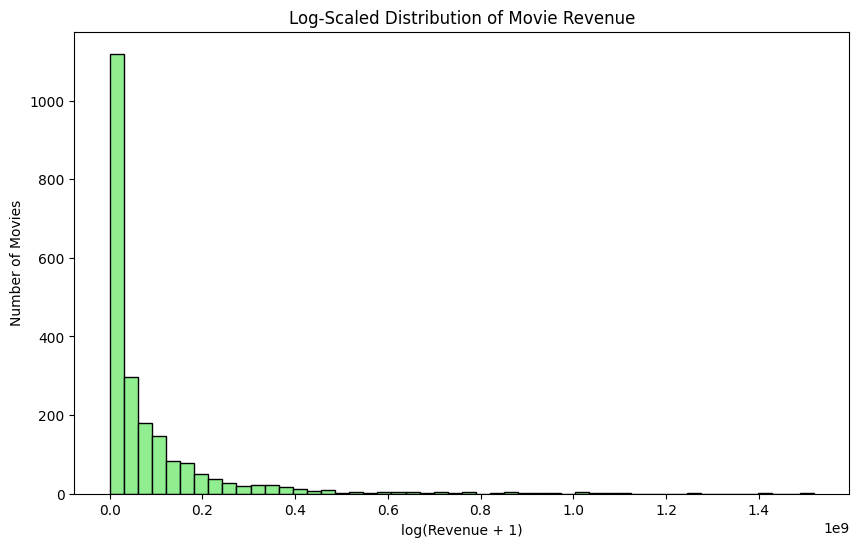

In [319]:
# revenue histogram
plt.figure(figsize=(10,6))
plt.hist(df['revenue'], bins=50, color='lightgreen', edgecolor='black')
plt.title('Log-Scaled Distribution of Movie Revenue')
plt.xlabel('log(Revenue + 1)')
plt.ylabel('Number of Movies')
plt.show()

● Majority of movies have moderate to high revenue
● Few movies have very low revenue, which appear as a small tail on the left side of the histogram

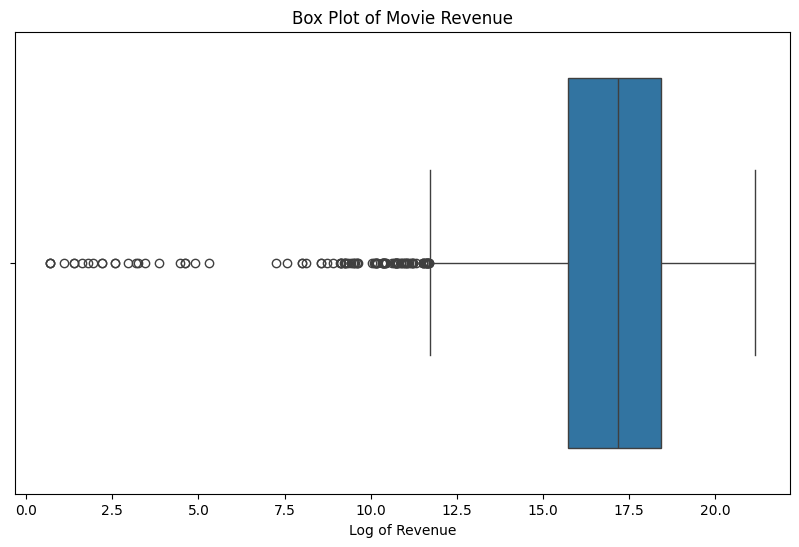

In [320]:
plt.figure(figsize=(10,6))
sns.boxplot(x=np.log1p(df['revenue']))  # log1p avoids log(0)
plt.xlabel('Log of Revenue')
plt.title('Box Plot of Movie Revenue')
plt.show()

# Univariate Analysis 

In [321]:
df.columns

Index(['budget', 'popularity', 'runtime', 'spoken_languages', 'revenue',
       'has_collection', 'genre_count', 'has_homepage', 'original_language_fr',
       'original_language_hi', 'original_language_ja',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'release_year', 'release_month',
       'release_dayofweek', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object')

'budget', 'popularity', 'runtime', 'spoken_languages', 'revenue',
       'has_collection', 'genre_count', 'has_homepage', 'original_language_fr',
       'original_language_hi', 'original_language_ja',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'release_year', 'release_month',
       'release_dayofweek', 'keyword_score', 'cast_score', 'director_score']

# Summary Statistics

In [322]:
# Numerical summary
num_cols = ['budget','popularity','runtime','revenue','overview_length',
            'overview_word_count','company_score','keyword_score','cast_score','director_score']
df[num_cols].describe()

,budget,popularity,runtime,revenue,overview_length,overview_word_count,company_score,keyword_score,cast_score,director_score
count,2.188000e+03,2188.000000,2188.000000,2.188000e+03,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2175.000000
mean,3.089305e+07,9.700621,110.085009,8.696605e+07,304.134369,51.902651,65.861974,100.449726,70.259598,2.510805
std,4.026785e+07,13.753541,22.438619,1.554912e+08,160.229965,27.286338,68.840021,93.941881,48.187242,1.938272
min,1.000000e+00,0.001880,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.150000e+06,5.398055,95.750000,6.816828e+06,179.000000,31.000000,7.000000,30.000000,34.000000,1.000000
50%,1.600000e+07,8.323165,106.000000,2.891063e+07,284.000000,48.000000,39.000000,74.000000,62.000000,2.000000
75%,4.000000e+07,11.657305,121.000000,1.000342e+08,390.250000,67.000000,125.250000,145.000000,95.000000,3.000000
max,3.800000e+08,294.337037,338.000000,1.519558e+09,1000.000000,177.000000,330.000000,933.000000,358.000000,10.000000


In [323]:
cat_cols = ['has_collection','has_homepage','original_language_fr',
            'original_language_hi','original_language_ja','original_language_other','original_language_ru','genre_count']

df[cat_cols].describe()

,has_collection,has_homepage,original_language_fr,original_language_hi,original_language_ja,original_language_other,original_language_ru,genre_count
count,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000,2188.000000
mean,0.227605,0.353748,0.017824,0.017824,0.008227,0.055302,0.012797,2.614260
std,0.419382,0.478241,0.132343,0.132343,0.090348,0.228620,0.112424,1.129566
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


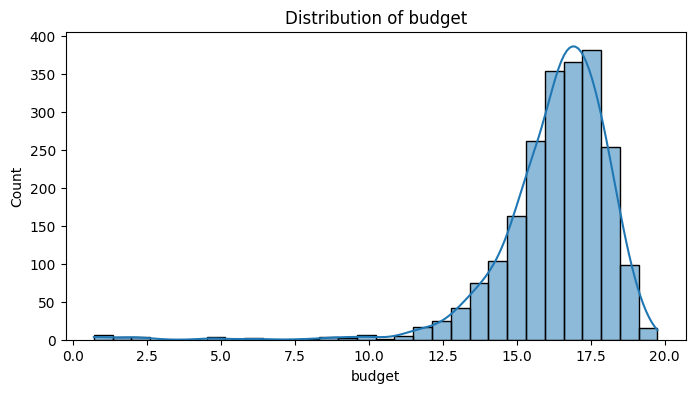

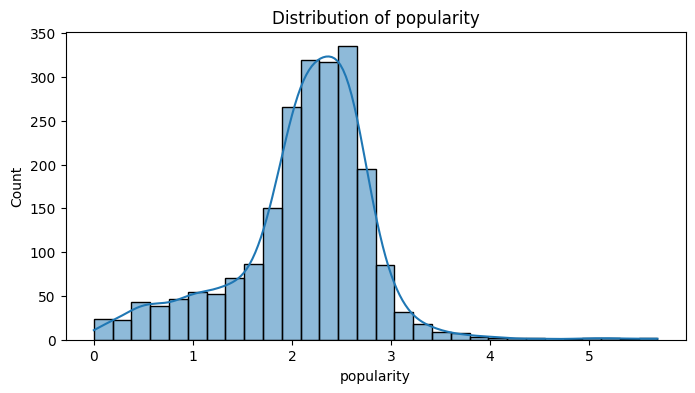

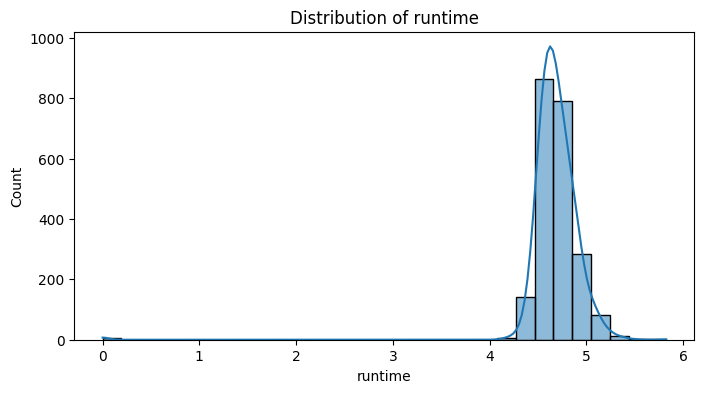

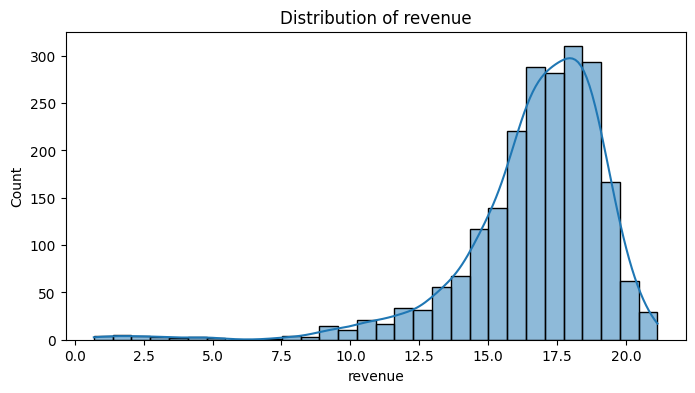

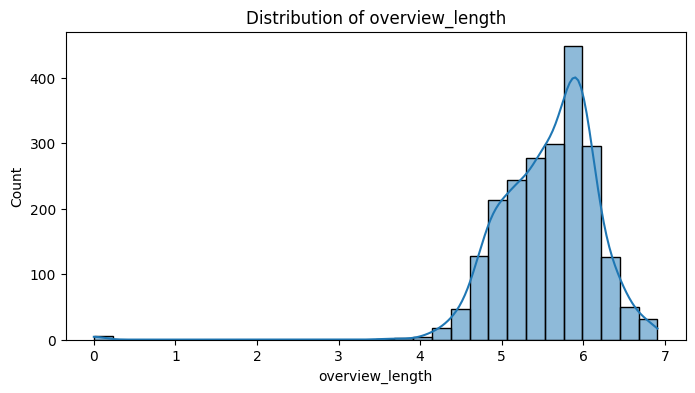

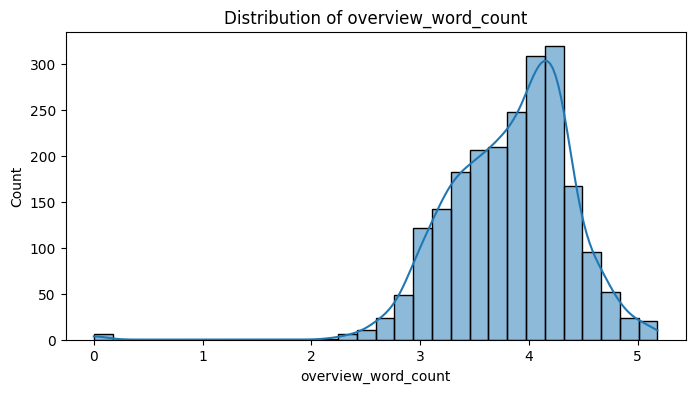

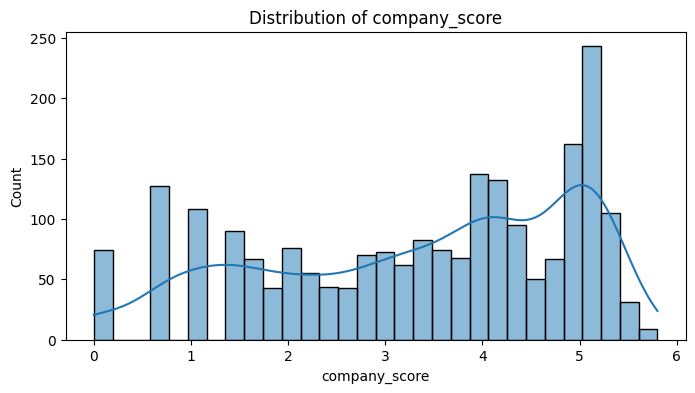

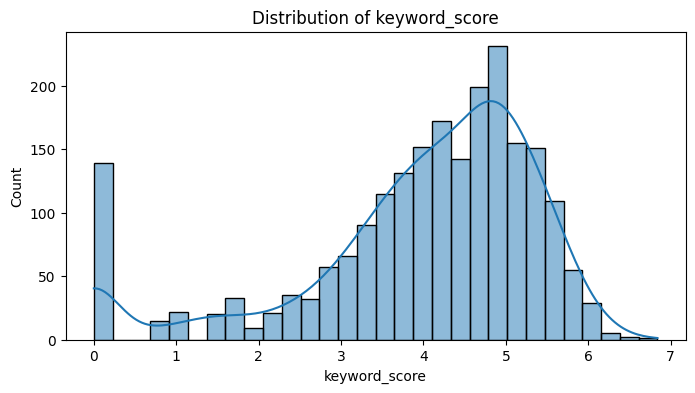

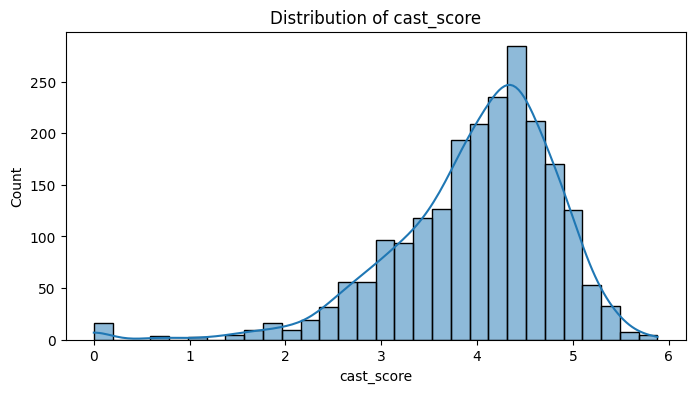

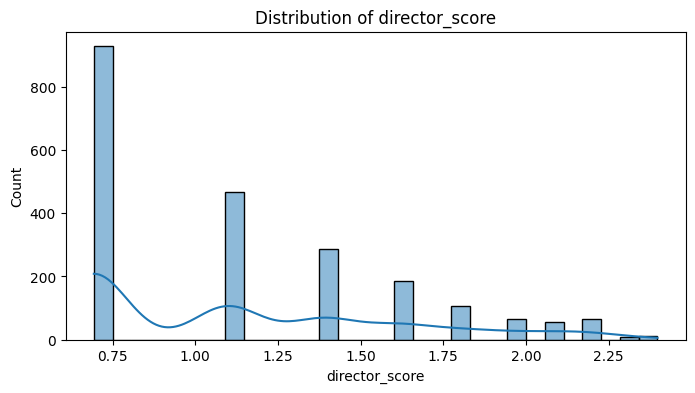

In [324]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(df[col]), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

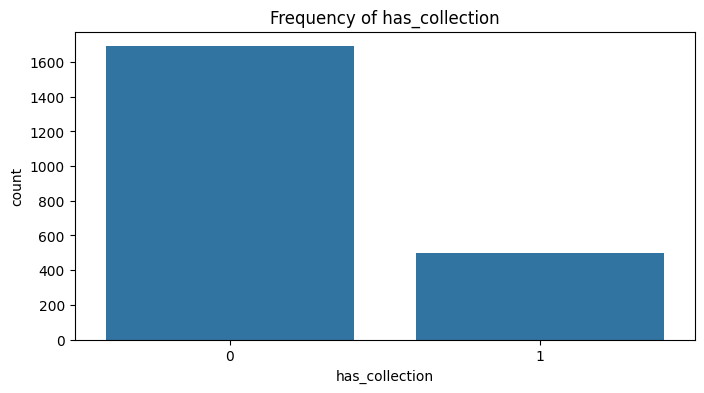

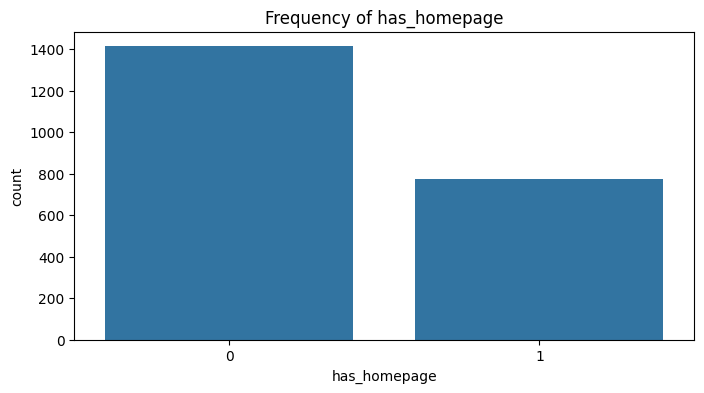

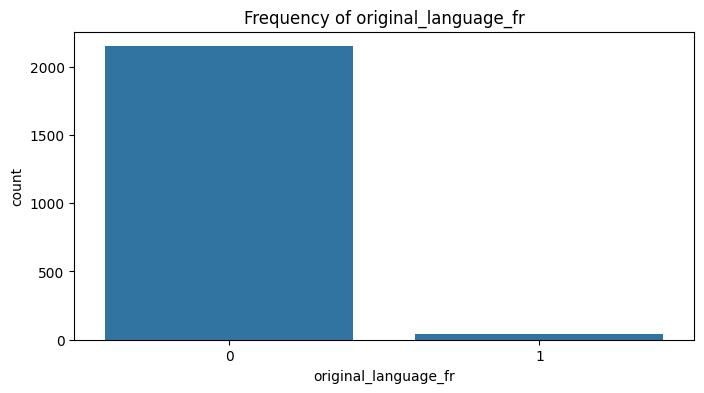

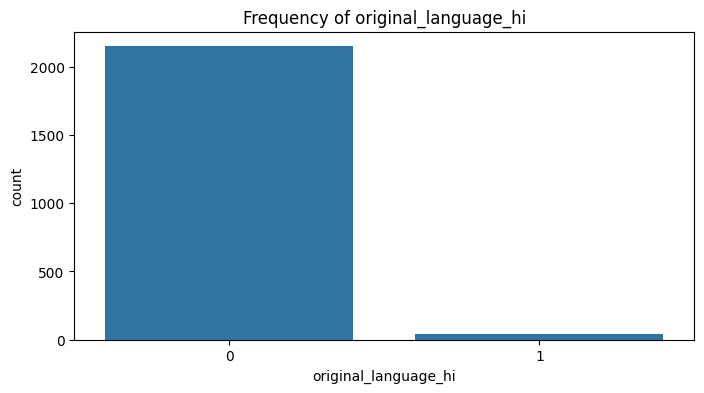

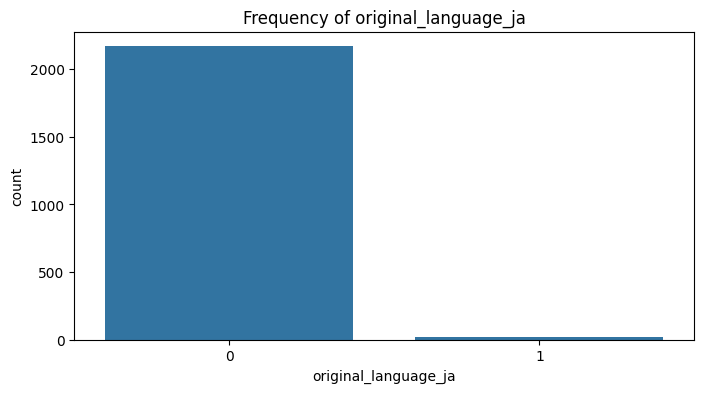

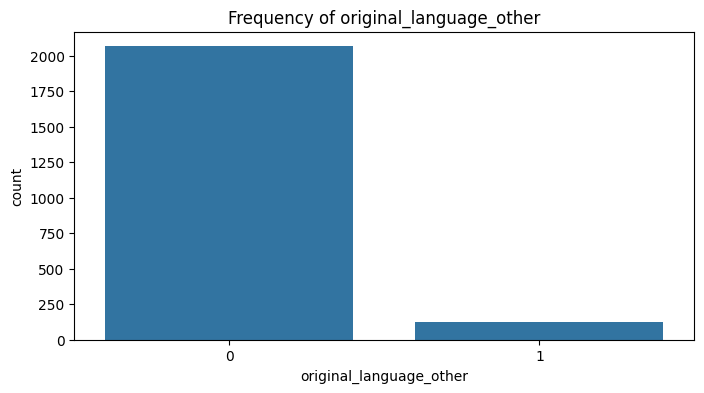

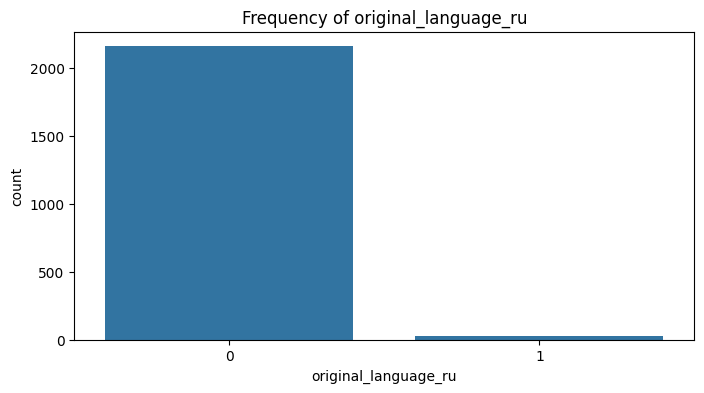

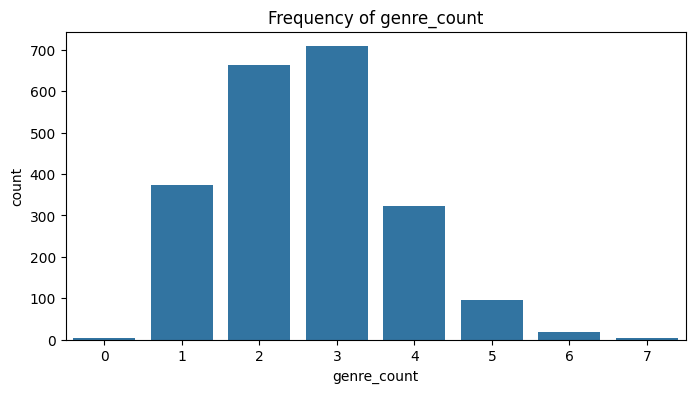

In [325]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'Frequency of {col}')
    plt.show()

# Bivariate Analysis 

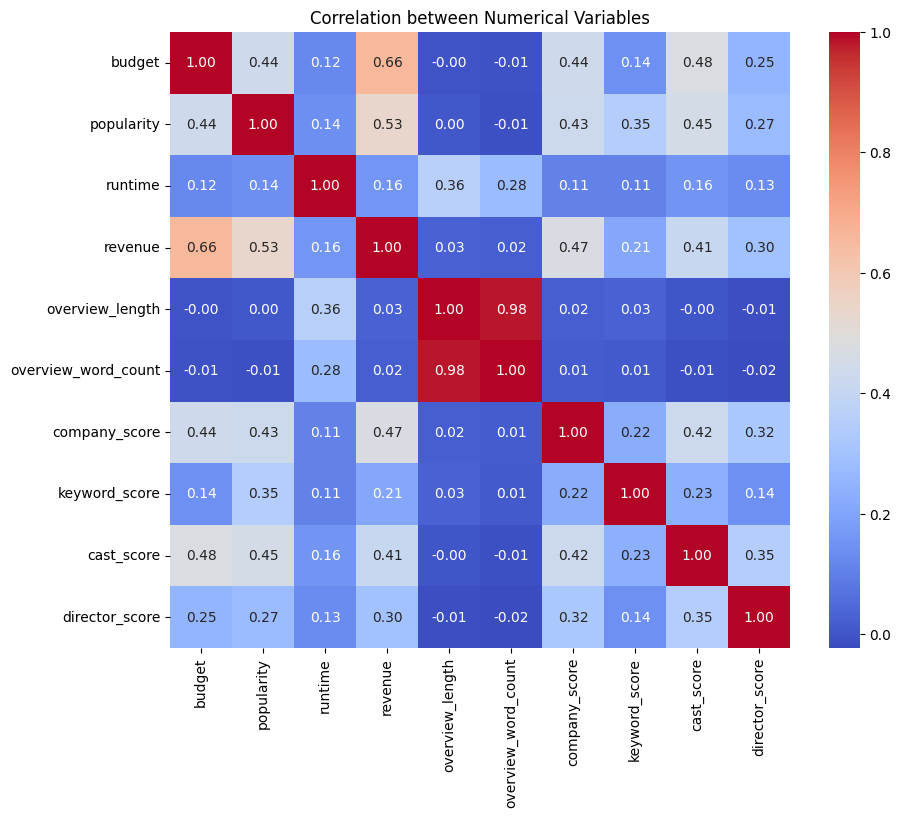

In [326]:
plt.figure(figsize=(10,8))
sns.heatmap( np.log1p(df[num_cols]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between Numerical Variables")
plt.show()

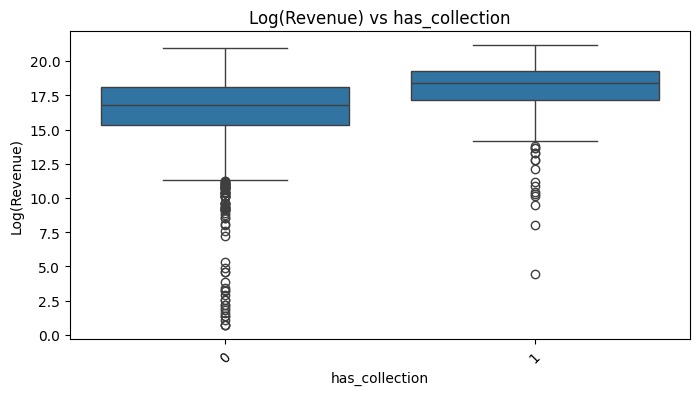

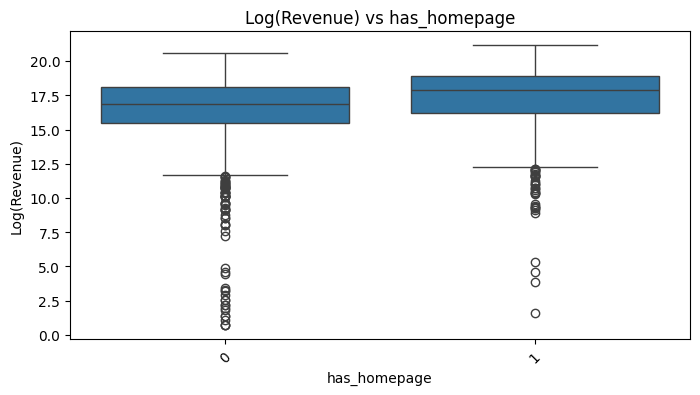

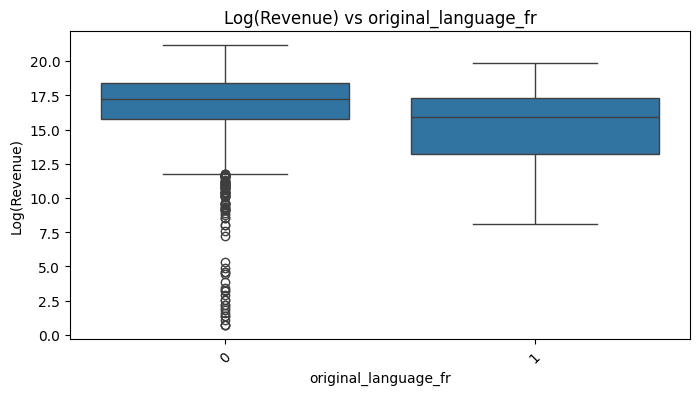

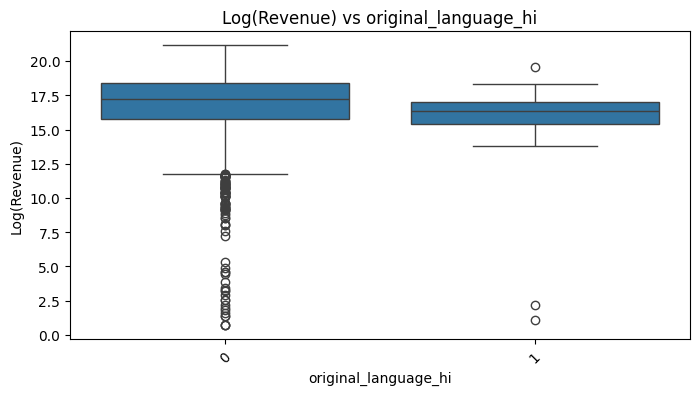

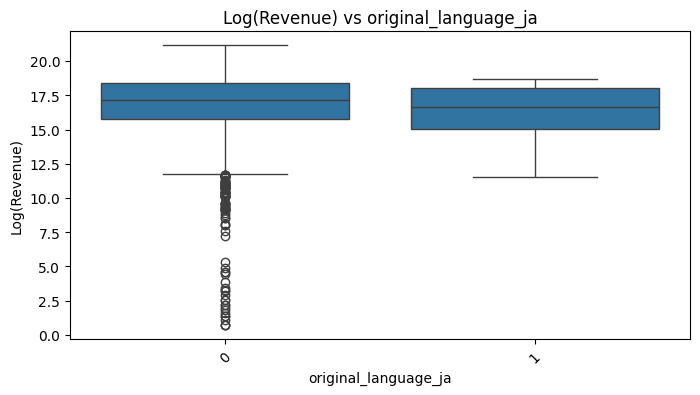

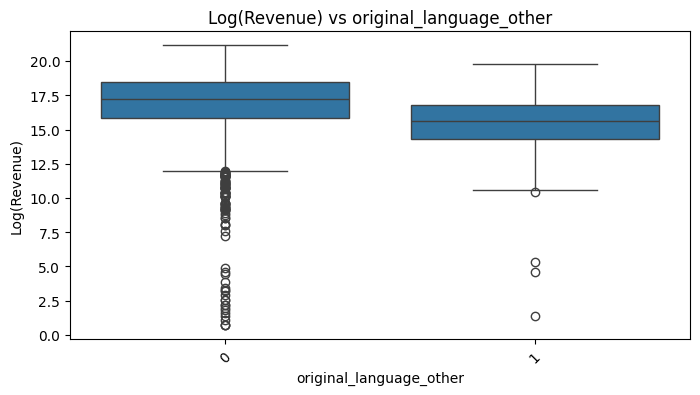

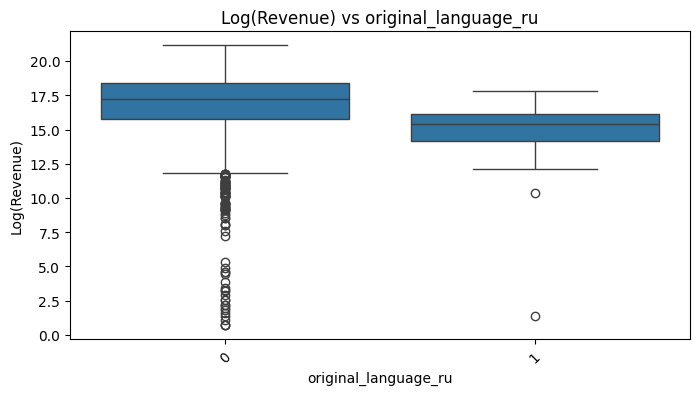

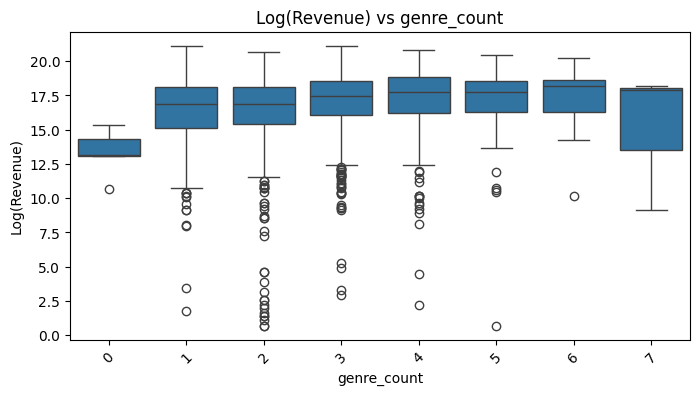

In [327]:
target = 'revenue'

for col in cat_cols:
    plt.figure(figsize=(8,4))
    # Use log scale for skewed revenue
    sns.boxplot(x=col, y=np.log1p(df[target]), data=df)
    plt.title(f'Log(Revenue) vs {col}')
    plt.ylabel('Log(Revenue)')
    plt.xticks(rotation=45)
    plt.show()

In [328]:
subset_cols = ['budget','popularity','runtime','revenue','cast_score','director_score']

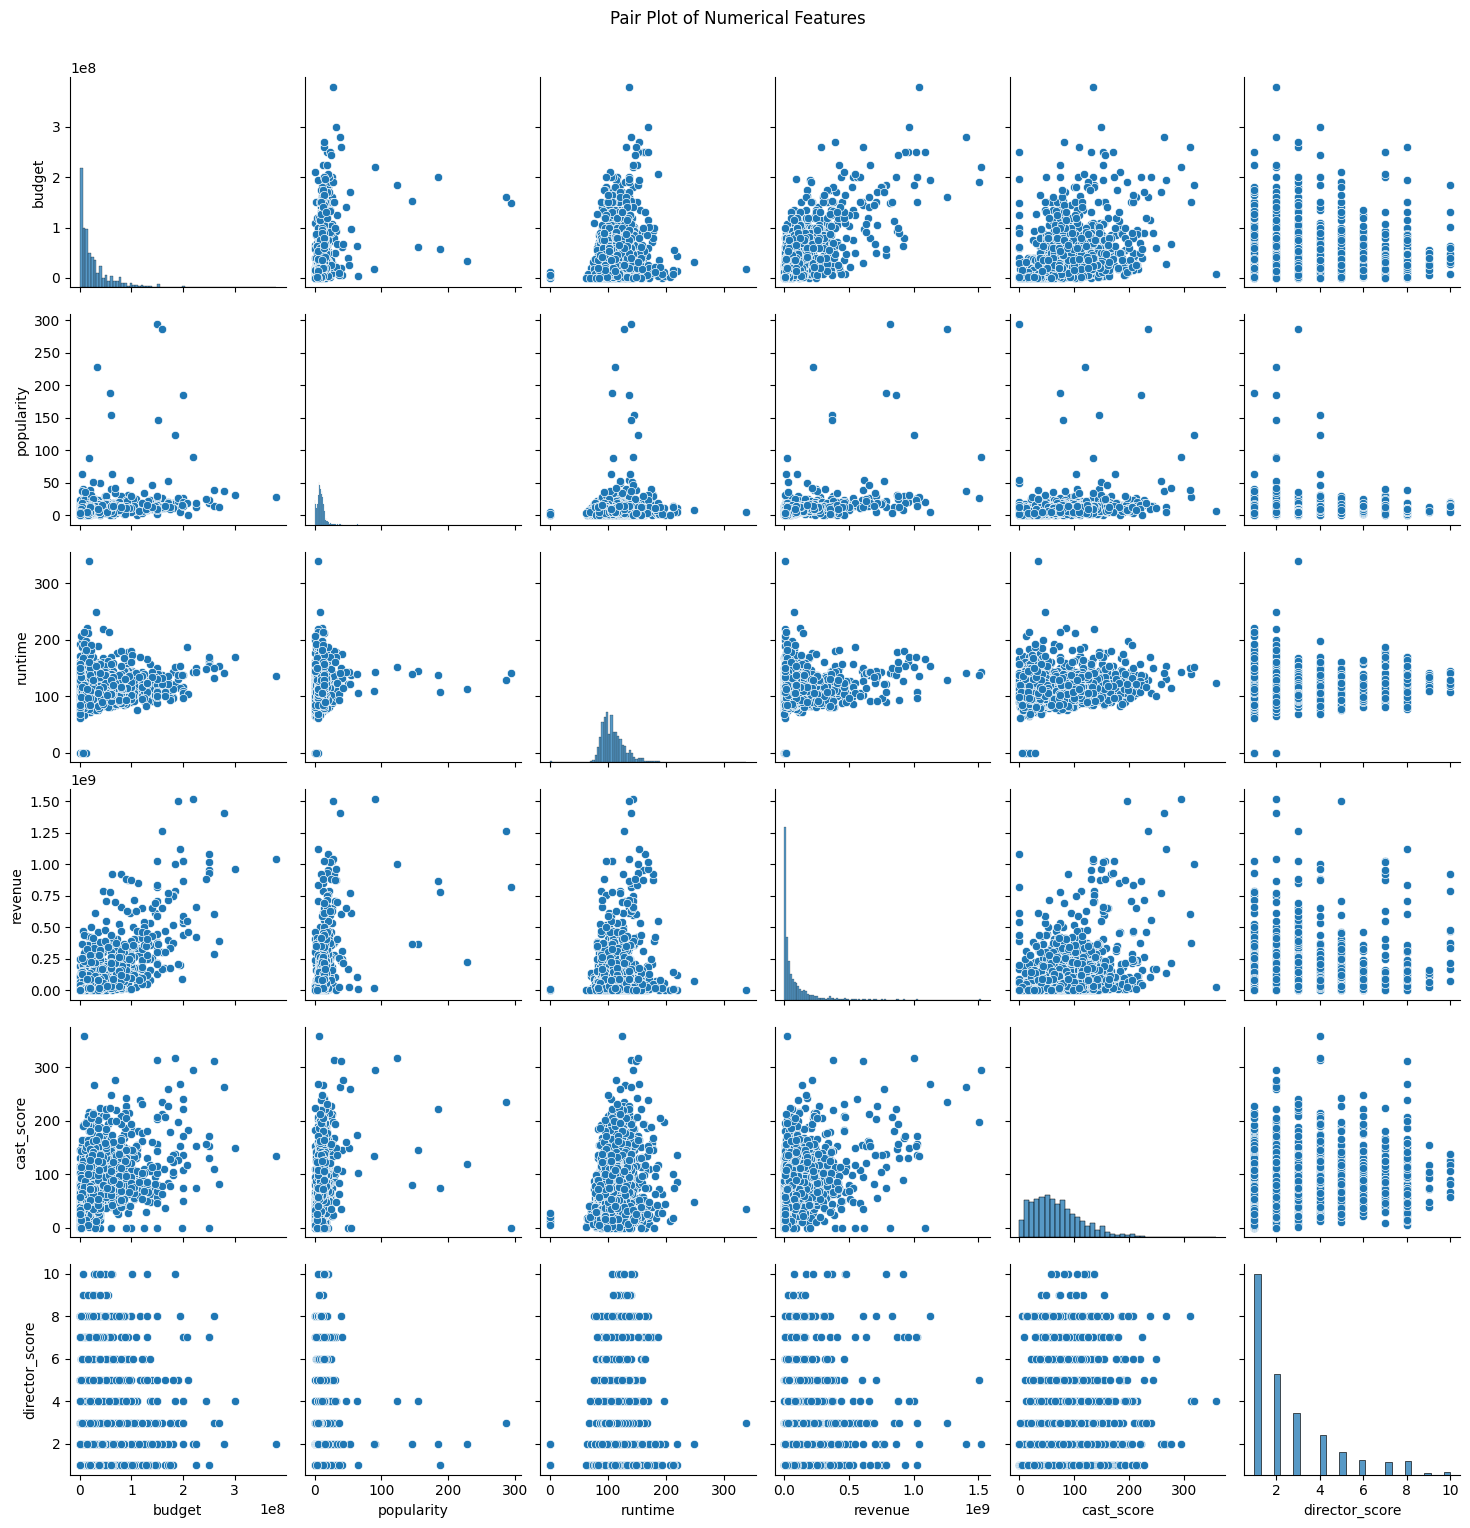

In [329]:
sns.pairplot(df[subset_cols])
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

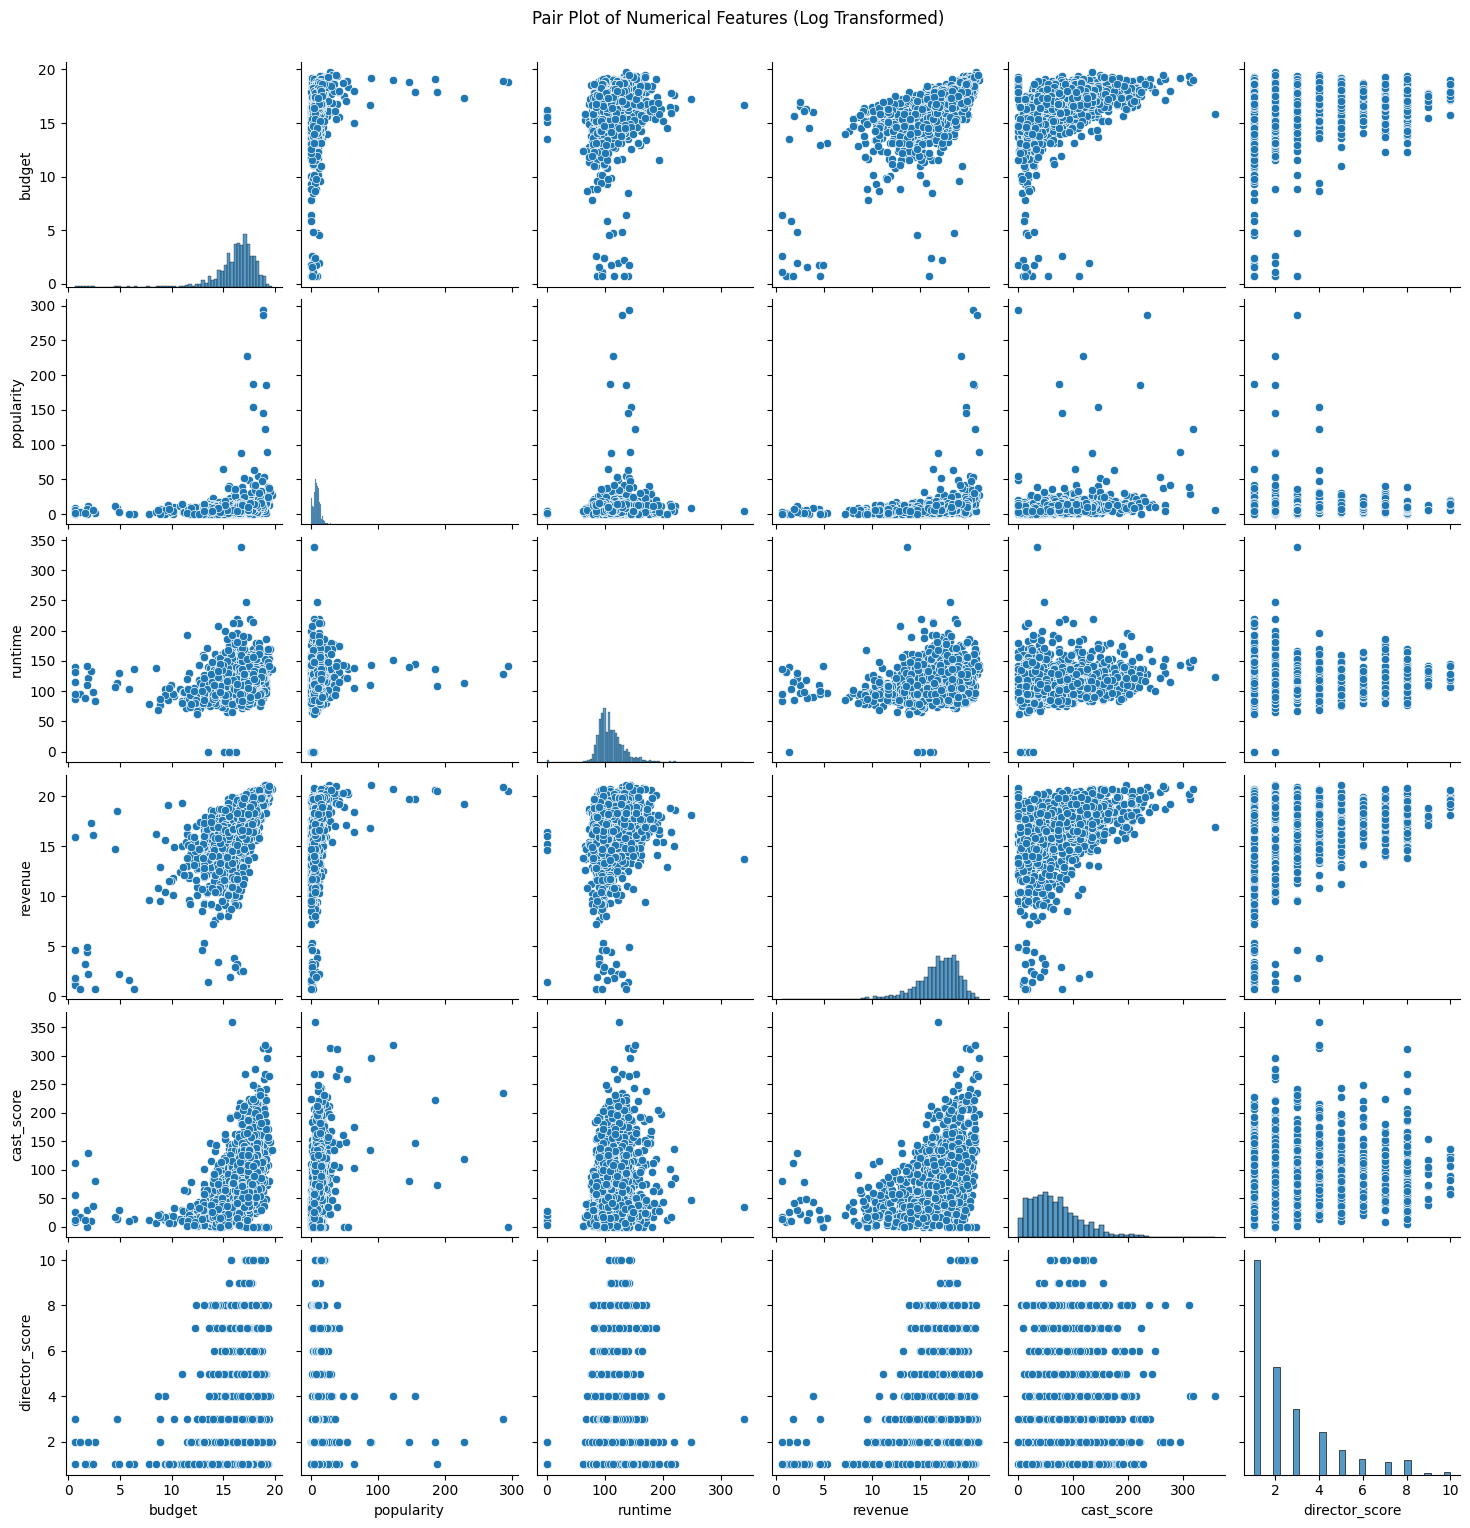

In [330]:
df_log = df[subset_cols].copy()
df_log['revenue'] = np.log1p(df_log['revenue'])
df_log['budget'] = np.log1p(df_log['budget'])

sns.pairplot(df_log)
plt.suptitle("Pair Plot of Numerical Features (Log Transformed)", y=1.02)
plt.show()

# feature engineering

## feature transformation

In [331]:
skewness = df[num_cols].skew()

print(skewness)

budget                  2.741932
popularity             13.184954
runtime                 1.320136
revenue                 3.937192
overview_length         1.135909
overview_word_count     1.150974
company_score           0.923261
keyword_score           1.669132
cast_score              1.232905
director_score          1.524578
dtype: float64


In [332]:
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_keyword_score'] = np.log1p(df['keyword_score'])
df['log_director_score'] = np.log1p(df['director_score'])
df['log_company_score'] = np.log1p(df['company_score'])

In [333]:
df['sqrt_cast_score'] = np.sqrt(df['cast_score'])
df['runtime'] = df['runtime'].replace(0, np.nan)
df['runtime_log'] = np.log1p(df['runtime'])

In [334]:
cols = ['log_budget', 'log_keyword_score', 'log_revenue']

for col in cols:
    lower = df[col].quantile(0.05)
    upper = df[col].quantile(0.95)
    df[col] = df[col].clip(lower, upper)

In [335]:
df['log_popularity'] = df['log_popularity'] ** 1.5
df['log_budget'] = df['log_budget'] ** 6
df['log_revenue'] = df['log_revenue'] ** 6
df['log_keyword_score'] = df['log_keyword_score'] ** 3

In [336]:
skewed_cols = ['log_budget','log_revenue','log_popularity','log_keyword_score','log_director_score',
               'sqrt_cast_score','runtime_log']
print(df[skewed_cols].skew())

log_budget            0.181191
log_revenue           0.303759
log_popularity        0.707830
log_keyword_score     0.123023
log_director_score    0.747051
sqrt_cast_score       0.141816
runtime_log           0.757135
dtype: float64


In [337]:
drop_col=['budget','revenue','popularity','keyword_score','cast_score','runtime']
df.drop(columns=drop_col,inplace=True)

In [338]:
df['avg_word_length'] = df['overview_length'] / df['overview_word_count']
df = df.drop(columns=['overview_length', 'overview_word_count'])

'log_budget',	'log_revenue',	'log_popularity'	'log_keyword_score',	'log_director_score' , 'sqrt_cast_score',	'sqrt_runtime',  'avg_word_length'

log_keyword_score,sqrt_runtime for dropping consideration

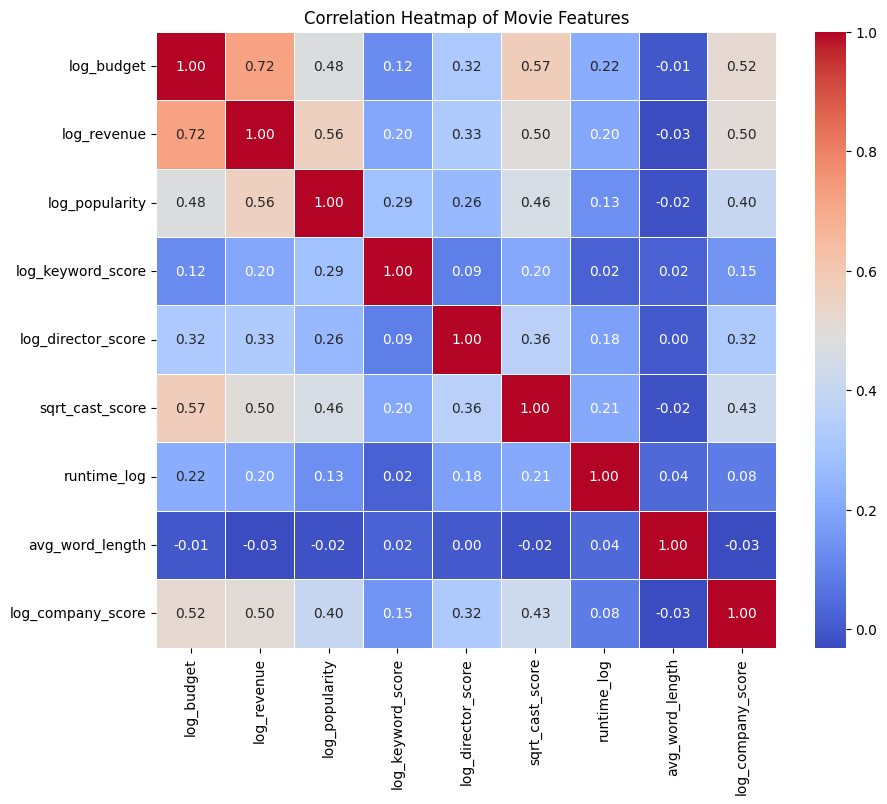

In [339]:
cols = [
    'log_budget', 'log_revenue', 'log_popularity', 
    'log_keyword_score', 'log_director_score', 
    'sqrt_cast_score', 'runtime_log', 'avg_word_length','log_company_score'
]

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Movie Features")
plt.show()

In [340]:
df = df.drop(columns=['avg_word_length'])

In [341]:
#cat col trans formation
target = 'log_revenue'

In [342]:
for col in cat_cols:
    pivot = pd.pivot_table(
        df,
        values=target,
        index=col,
        aggfunc='mean'
    )
    print(f"\nPivot for {col}:\n", pivot)


Pivot for has_collection:
                  log_revenue
has_collection              
0               2.452948e+07
1               3.735813e+07

Pivot for has_homepage:
                log_revenue
has_homepage              
0             2.469434e+07
1             3.248240e+07

Pivot for original_language_fr:
                        log_revenue
original_language_fr              
0                     2.762803e+07
1                     1.760356e+07

Pivot for original_language_hi:
                        log_revenue
original_language_hi              
0                     2.758217e+07
1                     2.013025e+07

Pivot for original_language_ja:
                        log_revenue
original_language_ja              
0                     2.749203e+07
1                     2.230376e+07

Pivot for original_language_other:
                           log_revenue
original_language_other              
0                        2.804462e+07
1                        1.728046e+07

Pivot for 

In [343]:
corr, p = pointbiserialr(df['has_collection'], df['log_revenue'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.34083157525710606
P-value: 1.2053707635267945e-60


In [344]:
drop_cols = [
    'original_language_ja',
    'original_language_fr',
    'original_language_hi',
    'original_language_ru',
    'original_language_other'
]
df = df.drop(columns=drop_cols)

In [345]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'] = df['movie_age'].clip(lower=0)  # remove negatives
df['movie_age_log'] = np.log1p(df['movie_age'])

In [346]:
df['is_peak_season'] = df['release_month'].isin([5,6,7,11,12]).astype(int)

In [347]:
df['is_friday_release'] = (df['release_dayofweek'] == 4).astype(int)

In [348]:
df['is_french'] = (df['spoken_languages'] == 'fr').astype(int)
df = df.drop(columns=['spoken_languages','director_score','company_score','release_year','release_month','release_dayofweek'])

## feature creation

In [349]:
df['budget_popularity'] = df['log_budget'] * df['log_popularity']
df['collection_popularity'] = df['has_collection'] * df['log_popularity']
df['company_director'] = df['log_company_score'] * df['log_director_score']

In [350]:
df['genre_count_sq'] = df['genre_count'] ** 2
df['movie_age_log'] = np.sqrt(df['movie_age'])

In [351]:
df = df.drop(columns=['log_budget','genre_count','log_popularity','movie_age','has_collection','log_company_score','log_director_score'])

In [352]:
df.skew()

has_homepage             0.612185
log_revenue              0.303759
log_keyword_score        0.123023
sqrt_cast_score          0.141816
runtime_log              0.757135
movie_age_log           -1.211012
is_peak_season           0.395328
is_friday_release        0.301559
is_french                0.000000
budget_popularity        1.776472
collection_popularity    2.074528
company_director         0.736995
genre_count_sq           1.592587
dtype: float64

In [353]:
drop_cols = ['is_french']

df = df.drop(columns=drop_cols)

In [354]:
X = df.drop(columns=['log_revenue'])  
y = df['log_revenue']   

In [355]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())


In [356]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y= df['log_revenue'].to_frame()
y_scaled = scaler.fit_transform(y)

In [357]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [358]:
X_scaled.head()

,has_homepage,log_keyword_score,sqrt_cast_score,runtime_log,movie_age_log,is_peak_season,is_friday_release,budget_popularity,collection_popularity,company_director,genre_count_sq
0,-0.739854,1.204447,0.448773,-0.856983,-0.663474,-0.821794,1.161964,-0.336415,1.137443,1.268873,-1.065636
1,-0.739854,-0.914391,0.448773,0.224128,0.234382,-0.821794,1.161964,0.330305,1.384248,0.877992,1.182640
2,1.351619,0.621592,0.789073,-0.183645,-0.567089,-0.821794,1.161964,0.369295,-0.492237,-0.636919,-1.065636
3,1.351619,-0.602290,-1.574375,0.649984,-0.385689,-0.821794,1.161964,-1.109281,-0.492237,-1.432700,-0.615981
4,-0.739854,-1.563578,-1.337979,-1.487355,1.250395,-0.821794,-0.860612,-1.216827,-0.492237,-1.432700,0.133444


# model training

In [359]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [360]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [361]:
y_pred = model.predict(X_test)

In [362]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.6545345529267074
R² Score: 0.5688174462170115


In [ ]:
y_true = y_test.values.ravel() if hasattr(y_test, 'values') else y_test
y_pred = y_pred.ravel()

plt.figure(figsize=(6,6))

# scatter
plt.scatter(y_true, y_pred, alpha=0.5)

# perfect prediction line (y = x)
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

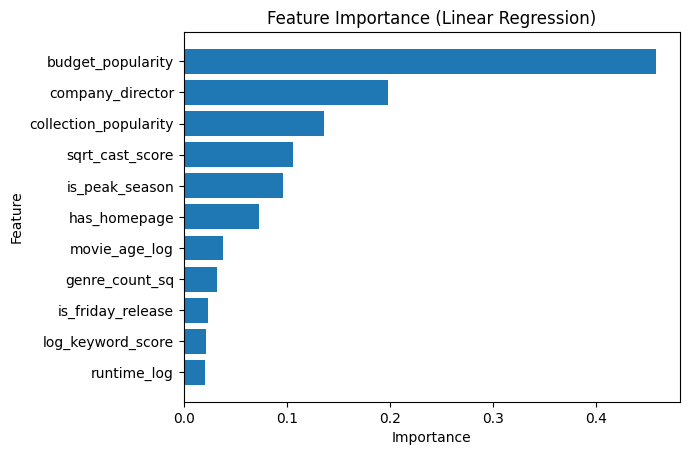

In [364]:
coefficients = model.coef_.ravel()

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Importance': np.abs(coefficients)
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

In [365]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores.mean())

0.5827490458246599


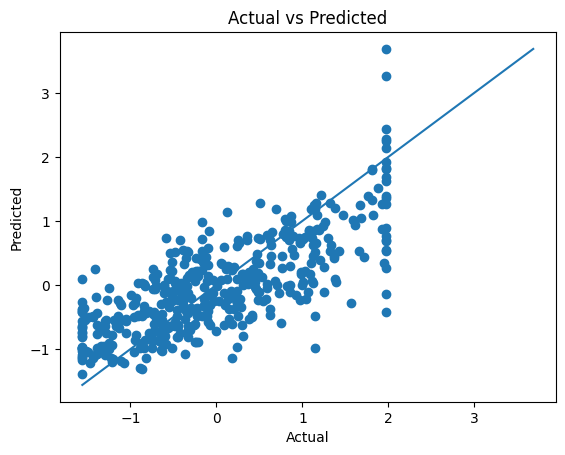

In [366]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [367]:
top_features = feature_importance['Feature'].head(5)

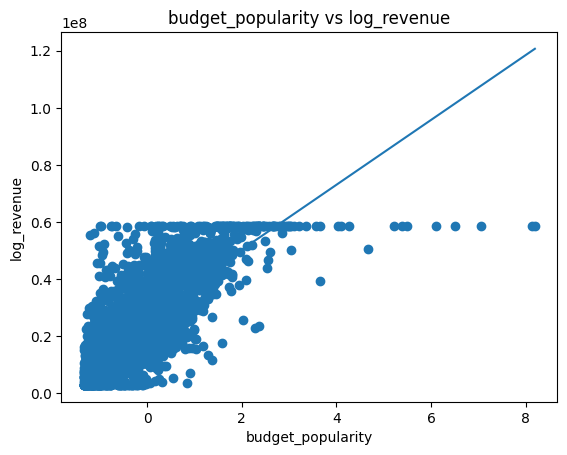

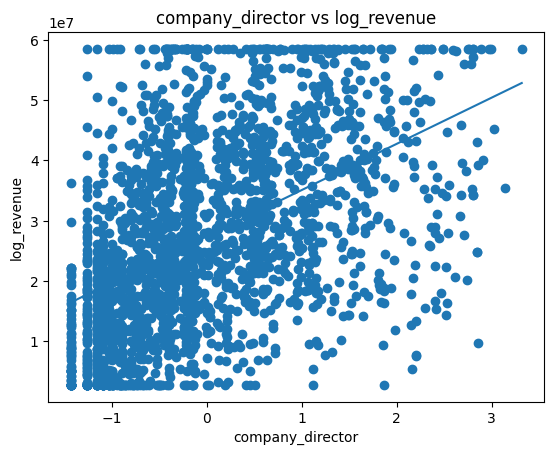

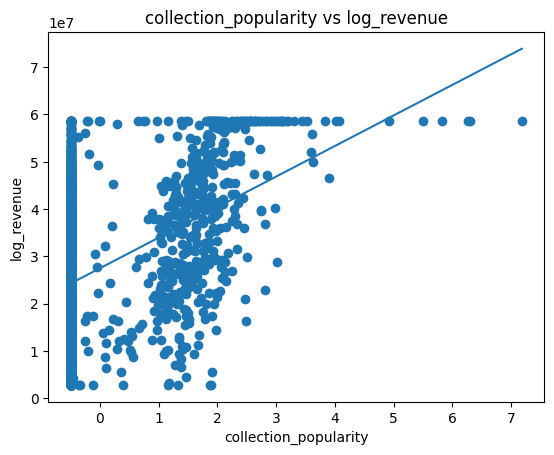

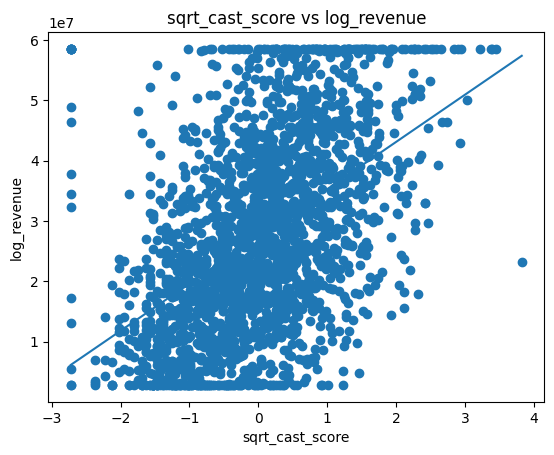

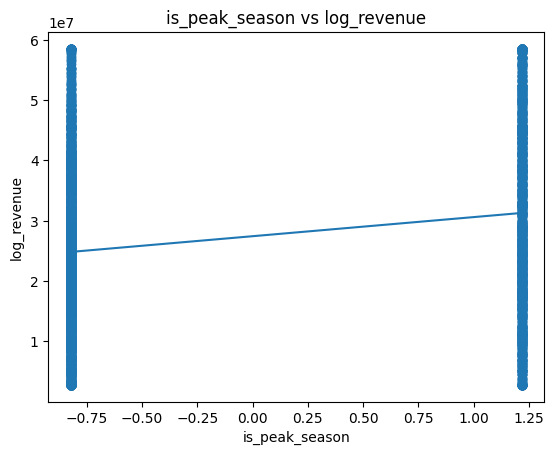

In [373]:
for feature in top_features:
    plt.figure()

    # ensure 1D arrays
    x = X_scaled[feature].values.ravel()
    y_1d = y.values.ravel() if hasattr(y, 'values') else y.ravel()

    plt.scatter(x, y_1d)

    # regression line
    z = np.polyfit(x, y_1d, 1)
    p = np.poly1d(z)

    # sort for smooth line
    sorted_idx = np.argsort(x)
    plt.plot(x[sorted_idx], p(x[sorted_idx]))

    plt.xlabel(feature)
    plt.ylabel("log_revenue")
    plt.title(f"{feature} vs log_revenue")

    plt.show()

In [374]:
X_train_top_feat=X_train[top_features]
X_test_top_feat=X_test[top_features]
X_train_top_feat.head()

,budget_popularity,company_director,collection_popularity,sqrt_cast_score,is_peak_season
552,2.877716,1.451182,2.898411,0.274117,1.216851
765,-0.301738,-0.617893,1.292108,-0.675160,1.216851
479,1.631153,0.671729,-0.492237,1.721803,-0.821794
256,0.680229,2.735001,-0.492237,0.233903,-0.821794
1488,-1.111648,-1.034810,0.885064,-1.523359,1.216851


In [375]:
model_top_feat=LinearRegression()
model_top_feat.fit(X_train_top_feat, y_train)

LinearRegression()

In [376]:
y_pred_top_feat = model_top_feat.predict(X_test_top_feat)

In [377]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_top_feat))
r2 = r2_score(y_test, y_pred_top_feat)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.656078052043516
R² Score: 0.5667814510142353


In [378]:
X1=X[top_features]

scores = cross_val_score(model_top_feat, X1, y, cv=5, scoring='r2')
print(scores.mean())

0.5789606226441225


In [379]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor( n_estimators=300,
    max_depth=6,
    min_samples_split=16,
    min_samples_leaf=12,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/Users/abinash/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [380]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.5702011642959043
R² Score: 0.6753213744387352


In [381]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.6302307671059556
R² Score: 0.6002437828955756


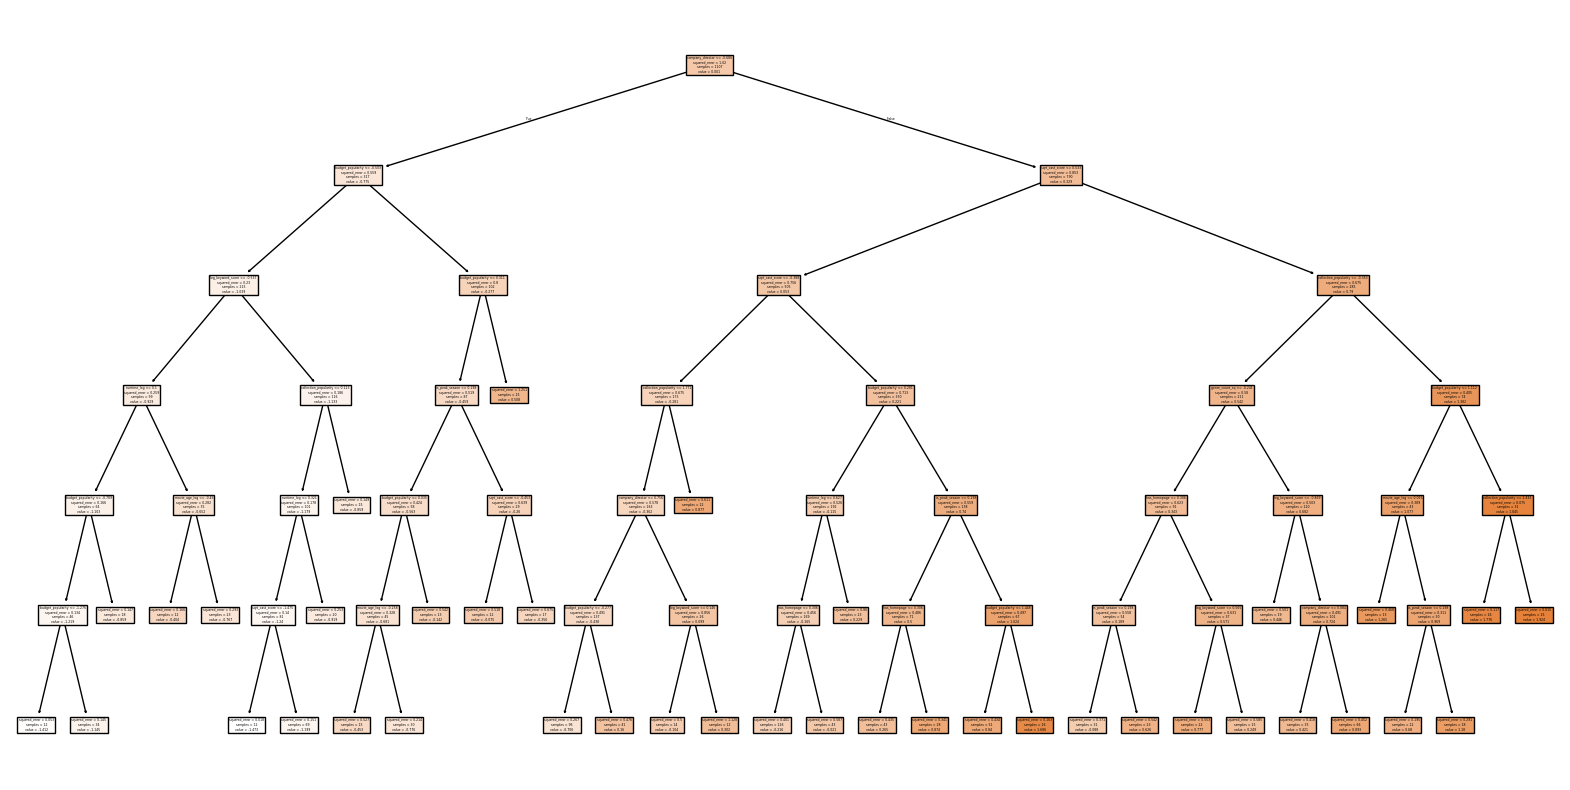

In [382]:
# pick one tree
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

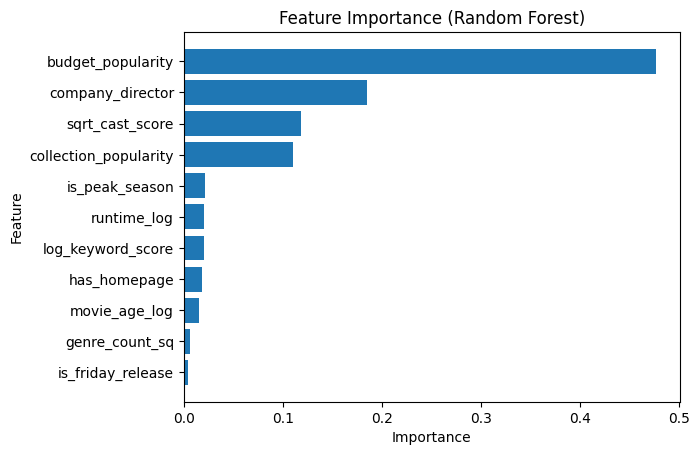

In [383]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

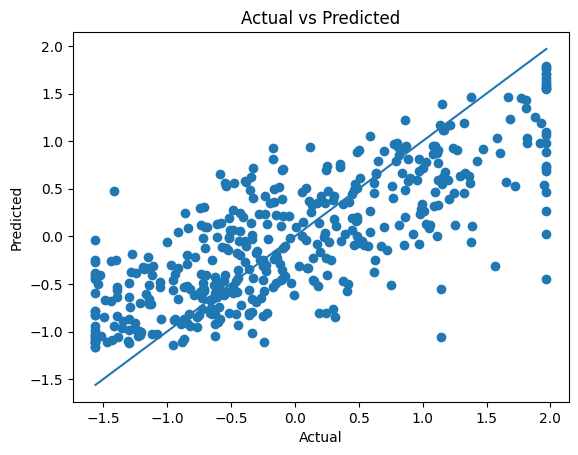

In [384]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [385]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.02,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [386]:
y_train_pred = model.predict(X_train)
rmse = np.sqrt(mean_squared_error( y_train,y_train_pred))
r2 = r2_score(y_train, y_train_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.573826750008513
R² Score: 0.6711793534290664


In [387]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.6164509633427728
R² Score: 0.6175337693309363


<Figure size 500000x500000 with 0 Axes>

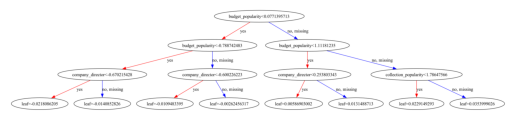

In [388]:
from xgboost import plot_tree
# pick one tree
plt.figure(figsize=(5000, 5000))
plot_tree(model, num_trees=0)  # first tree
plt.show()

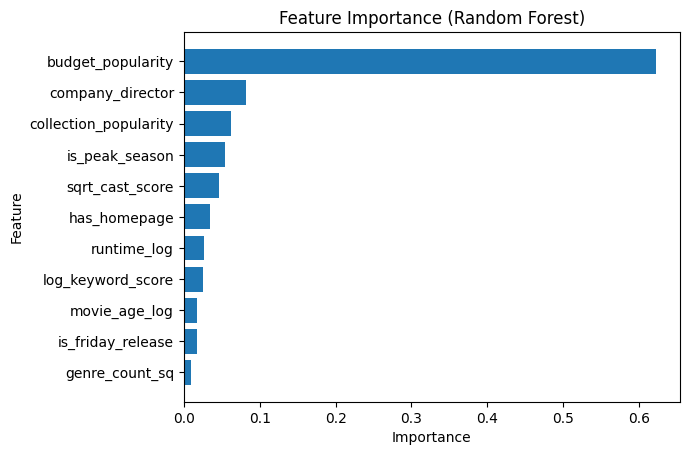

In [389]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

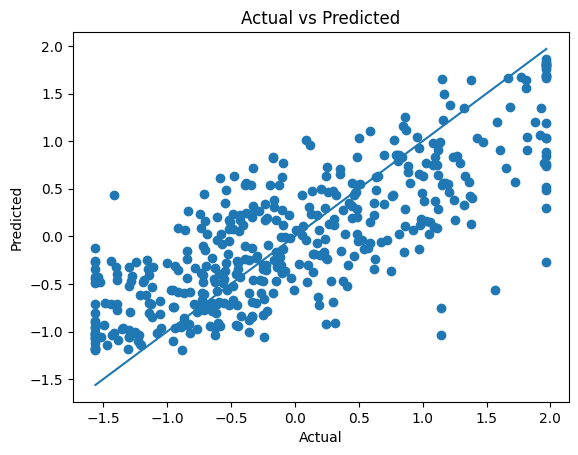

In [390]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [391]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

/Users/abinash/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [392]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.6245363905725412
R² Score: 0.607435048814545


## base models
random forest, xgboost